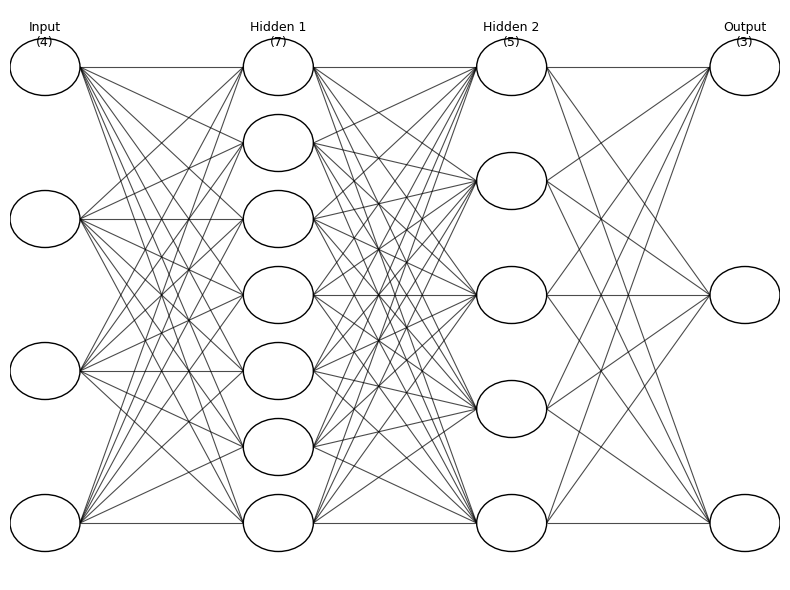

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle


def draw_neural_network(
    layer_sizes, figsize=(8, 6), node_radius=0.05, edge_color="black"
):
    """
    Draw a simple neural network diagram.
    - layer_sizes: list of ints, number of nodes per layer (e.g., [3, 5, 4, 1])
    """
    n_layers = len(layer_sizes)
    # horizontal positions for layers
    xs = np.linspace(0, 1, n_layers)

    # compute node coordinates for each layer
    coords = []
    for i, (x, n) in enumerate(zip(xs, layer_sizes)):
        # center nodes vertically
        if n == 1:
            ys = np.array([0.5])
        else:
            ys = np.linspace(0.1, 0.9, n)
        coords.append([(x, y) for y in ys])

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(0, 1)
    ax.axis("off")

    # draw edges
    segments = []
    for i in range(n_layers - 1):
        for x1, y1 in coords[i]:
            for x2, y2 in coords[i + 1]:
                segments.append([(x1 + node_radius, y1), (x2 - node_radius, y2)])
    lc = LineCollection(segments, colors=edge_color, linewidths=0.8, alpha=0.7)
    ax.add_collection(lc)

    # draw nodes
    for layer_idx, layer in enumerate(coords):
        for node_idx, (x, y) in enumerate(layer):
            circ = Circle((x, y), node_radius, ec="k", fc="w", zorder=3)
            ax.add_patch(circ)

    # annotate layer labels
    for i, size in enumerate(layer_sizes):
        label = (
            "Input" if i == 0 else ("Output" if i == n_layers - 1 else f"Hidden {i}")
        )
        ax.text(xs[i], 0.98, f"{label}\n({size})", ha="center", va="top", fontsize=9)

    plt.tight_layout()
    plt.show()


# Example usage:
draw_neural_network([4, 7, 5, 3])

# Hidden Markov Model (HMM) diagram
This notebook renders the HMM diagram using Graphviz only.

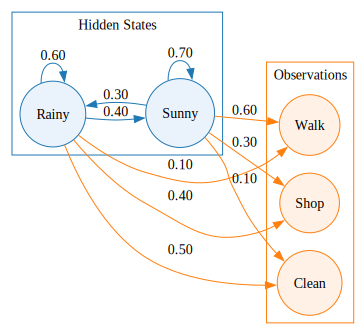

In [ ]:
from typing import List, Tuple
from graphviz import Digraph


def render_hmm_graphviz(
    state_labels: List[str],
    observation_labels: List[str],
    transitions: List[Tuple[str, str, float]],
    emissions: List[Tuple[str, str, float]],
):
    dot = Digraph("HMM", format="png")
    dot.attr(rankdir="LR")
    with dot.subgraph(name="cluster_states") as cs:
        cs.attr(label="Hidden States", color="#1f77b4")
        for s in state_labels:
            cs.node(
                f"s_{s}",
                s,
                shape="circle",
                style="filled",
                fillcolor="#eaf2fb",
                color="#1f77b4",
            )
    with dot.subgraph(name="cluster_obs") as co:
        co.attr(label="Observations", color="#ff7f0e")
        for o in observation_labels:
            co.node(
                f"o_{o}",
                o,
                shape="circle",
                style="filled",
                fillcolor="#fff1e6",
                color="#ff7f0e",
            )
    for src, dst, p in transitions:
        dot.edge(f"s_{src}", f"s_{dst}", label=f"{p:.2f}", color="#1f77b4")
    for src, dst, p in emissions:
        dot.edge(f"s_{src}", f"o_{dst}", label=f"{p:.2f}", color="#ff7f0e")
    return dot


states = ["Rainy", "Sunny"]
observations = ["Walk", "Shop", "Clean"]
transitions = [
    ("Rainy", "Rainy", 0.6),
    ("Rainy", "Sunny", 0.4),
    ("Sunny", "Rainy", 0.3),
    ("Sunny", "Sunny", 0.7),
]
emissions = [
    ("Rainy", "Walk", 0.1),
    ("Rainy", "Shop", 0.4),
    ("Rainy", "Clean", 0.5),
    ("Sunny", "Walk", 0.6),
    ("Sunny", "Shop", 0.3),
    ("Sunny", "Clean", 0.1),
]

render_hmm_graphviz(states, observations, transitions, emissions)

## Microservices architecture diagram
We render this microservices diagram using Graphviz only.

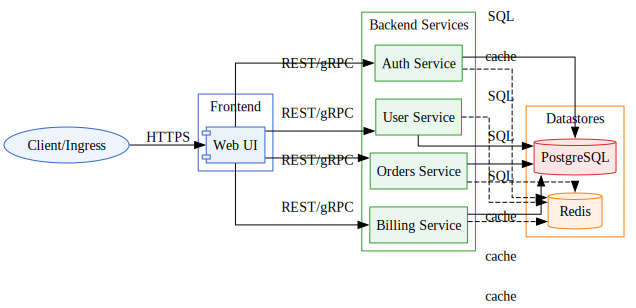

In [ ]:
from typing import Optional, Dict
from graphviz import Digraph
import os


def _icon_label(text: str, image_path: str, img_w: int = 48) -> str:
    """Return an HTML-like Graphviz label embedding an image and caption."""
    return f'''<
<TABLE BORDER="0" CELLBORDER="0" CELLPADDING="2">
  <TR><TD><IMG SRC="{image_path}" SCALE="TRUE" WIDTH="{img_w}"/></TD></TR>
  <TR><TD><B>{text}</B></TD></TR>
</TABLE>
>'''


def microservices_graphviz(
    frontend: str,
    backends: list,
    redis_label: str,
    postgres_label: str,
    ingress: Optional[str] = "Client/Ingress",
    icons: Optional[Dict] = None,
):
    """
    Render a microservices architecture with optional logos.

    icons (optional) structure:
      {
        'frontend': 'icons/frontend.png',
        'redis': 'icons/redis.png',
        'postgres': 'icons/postgres.png',
        'services': {
          'Auth Service': 'icons/auth.png',
          'User Service': 'icons/user.png',
          ...
        }
      }
    Only files that exist on disk will be used; others fall back to shape-based nodes.
    """
    icons = icons or {}
    dot = Digraph("Microservices", format="png")
    dot.attr(rankdir="LR", splines="ortho")

    # Ingress
    dot.node(
        "ingress",
        ingress,
        shape="oval",
        style="filled",
        fillcolor="#eef5ff",
        color="#3366cc",
    )

    # Frontend
    with dot.subgraph(name="cluster_frontend") as cf:
        cf.attr(label="Frontend", color="#3366cc")
        fe_icon = icons.get("frontend")
        if fe_icon and os.path.exists(fe_icon):
            cf.node("fe", label=_icon_label(frontend, fe_icon, 50), shape="none")
        else:
            cf.node(
                "fe",
                frontend,
                shape="component",
                style="filled",
                fillcolor="#eaf2fb",
                color="#3366cc",
            )

    # Backends
    with dot.subgraph(name="cluster_backend") as cb:
        cb.attr(label="Backend Services", color="#2ca02c")
        service_icons = (
            icons.get("services", {}) if isinstance(icons.get("services"), dict) else {}
        )
        for i, svc in enumerate(backends):
            node_id = f"svc{i}"
            svc_icon = service_icons.get(svc)
            if svc_icon and os.path.exists(svc_icon):
                cb.node(node_id, label=_icon_label(svc, svc_icon, 44), shape="none")
            else:
                cb.node(
                    node_id,
                    svc,
                    shape="box",
                    style="filled",
                    fillcolor="#e9f7ef",
                    color="#2ca02c",
                )

    # Datastores
    with dot.subgraph(name="cluster_data") as cd:
        cd.attr(label="Datastores", color="#ff7f0e")
        redis_icon = icons.get("redis")
        if redis_icon and os.path.exists(redis_icon):
            cd.node(
                "redis", label=_icon_label(redis_label, redis_icon, 44), shape="none"
            )
        else:
            cd.node(
                "redis",
                redis_label,
                shape="cylinder",
                style="filled",
                fillcolor="#fff1e6",
                color="#ff7f0e",
            )

        pg_icon = icons.get("postgres")
        if pg_icon and os.path.exists(pg_icon):
            cd.node("pg", label=_icon_label(postgres_label, pg_icon, 44), shape="none")
        else:
            cd.node(
                "pg",
                postgres_label,
                shape="cylinder",
                style="filled",
                fillcolor="#ffe6e6",
                color="#d62728",
            )

    # Edges
    dot.edge("ingress", "fe", label="HTTPS")
    for i, _ in enumerate(backends):
        dot.edge("fe", f"svc{i}", label="REST/gRPC")
        dot.edge(f"svc{i}", "redis", style="dashed", label="cache")
        dot.edge(f"svc{i}", "pg", label="SQL")

    return dot


# Attempt to auto-download Redis/Postgres logos into icons/ if not provided
import urllib.request


def _ensure_icon(path: str, urls: list) -> Optional[str]:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    if os.path.exists(path):
        return path
    for url in urls:
        try:
            urllib.request.urlretrieve(url, path)
            if os.path.exists(path) and os.path.getsize(path) > 0:
                return path
        except Exception:
            continue
    return None


frontend = "Web UI"
backends = ["Auth Service", "User Service", "Orders Service", "Billing Service"]
redis_label = "Redis"
postgres_label = "PostgreSQL"

# Candidate logo URLs (prefer PNG for Graphviz image embedding)
redis_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/thumb/6/6b/Redis_Logo.svg/96px-Redis_Logo.svg.png"
]
postgres_urls = [
    "https://upload.wikimedia.org/wikipedia/commons/thumb/2/29/Postgresql_elephant.svg/96px-Postgresql_elephant.svg.png"
]

icons = {
    "redis": _ensure_icon("icons/redis.png", redis_urls),
    "postgres": _ensure_icon("icons/postgres.png", postgres_urls),
    # 'frontend': 'icons/frontend.png',
    # 'services': { 'Auth Service': 'icons/auth.png' }
}

microservices_graphviz(frontend, backends, redis_label, postgres_label, icons=icons)

### Optional logos for services and datastores
- Save PNG/SVG files under an `icons/` folder in this workspace (e.g., `icons/redis.png`, `icons/postgres.png`).
- Update the `icons` mapping in the microservices cell to point to those files.
- Note: Ensure you have rights to use any logos you include. Many vendor logos are trademarked and have usage guidelines.